<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Input_Engineering1_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This week covers three topics related to engineering (changing) the variables or attributes being used.

1. Constructing new attributes (application specific)

2. Selecting a subset of attributes to use (Boruta)

3. Transforming the data to different space (PCA)

#**Atribute Construction**

In [32]:
pkgs <- c("titanic")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [33]:
library (titanic)

str (titanic_train)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : Factor w/ 2 levels "0","1": 1 2 2 2 1 1 1 1 2 2 ...
 $ Pclass     : Factor w/ 3 levels "1","2","3": 3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...


In [34]:
titanic_train$Survived = factor (titanic_train$Survived)
titanic_train$Pclass = factor (titanic_train$Pclass)

This is a simple demonstration of adding a useful constructed variable

We saw in a previous demo, treating Age as a factor variables resulted is not a variable that is highly predictive of survival (p = 0.1014 using Chi-Squated test)

---
Chi-squared test is a statistical hypothesis test used to determine if there's a significant association between 2 categorical variables.

X-squared: the calculated Chi-squared test statistic. The larger X-squared value indicates a greater discrepancy between observed and expected counts.

df (degree of freedom): the number of independent pieces of information used to calculate the statistic. For table, (nrows -1)*(ncols-1)

p-value: the probability of observing a test statistic as extreme as, or extreme than, the one calculated from the same data, assuming that the null hypothesis (no association) is true. A small p-value (<0.05) suggests that the observed association is statiscally significant.

---

In [35]:
tblAge = table (titanic_train$Survived, titanic_train$Age)
chisq.test (tblAge)

Warning message in chisq.test(tblAge):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tblAge
X-squared = 104.16, df = 87, p-value = 0.1014


It may be better as a continuous variable, but we'll leave that for now.

In [36]:
tblSex = table (titanic_train$Survived, titanic_train$Sex)
chisq.test (tblSex)
tblSex


	Pearson's Chi-squared test with Yates' continuity correction

data:  tblSex
X-squared = 260.72, df = 1, p-value < 2.2e-16


   
    female male
  0     81  468
  1    233  109

It maybe possible to create age groups that work better. You want to do some investigation to determine likely successful age groups.

I first create the new variable using the cut function

In [37]:
AgeGroups = cut (titanic_train$Age,
                 breaks = c(0,18,40,60,80),
                 labels = c("Child",
                            "Adult",
                            "MiddleAgeAdult",
                            "OlderAdult"))

I then combine it with previous data using the cbind() function (note that there is also rbind() function when you need to add rows to your data)

In [38]:
titanic_new = cbind (titanic_train, AgeGroups)

titanic_new$Age = NULL

Now we repeat the Chi-Squared test and get p = 0.02819 so the new variable is better (at least when treated as a factor or nominal variable)

In [39]:
tblAge = table (titanic_new$Survived, titanic_new$AgeGroups)

chisq.test (tblAge)
tblAge


	Pearson's Chi-squared test

data:  tblAge
X-squared = 9.0845, df = 3, p-value = 0.02819


   
    Child Adult MiddleAgeAdult OlderAdult
  0    69   260             78         17
  1    70   165             50          5

In [40]:
tblClass = table (titanic_new$Survived, titanic_new$Pclass)
chisq.test (tblClass)


	Pearson's Chi-squared test

data:  tblClass
X-squared = 102.89, df = 2, p-value < 2.2e-16


Say I want to add a variable that picks up "female" and first class, and assigns the label "female_P1", assigns "male_P3" to third class and "male", and assigns "others" to everyone else. I could use the following code to create the variable and then use cbind() to add this variable to the dataset as above.


In [41]:
ClassGender = NULL
for(i in 1:nrow(titanic_train)){
  if(titanic_train$Pclass[i]==1 & titanic_train$Sex[i] == "female") {
    ClassGender[i] = "female_P1"
  } else if (titanic_train$Pclass[i]==3 & titanic_train$Sex[i] == "male") {
    ClassGender[i] = "male_P3"
  } else {
    ClassGender[i] = "others"
  }
}

titanic_new = cbind(titanic_new,ClassGender)

tblClassGender = table(titanic_new$Survived,titanic_new$ClassGender)
chisq.test(tblClassGender)
tblClassGender


	Pearson's Chi-squared test

data:  tblClassGender
X-squared = 235.38, df = 2, p-value < 2.2e-16


   
    female_P1 male_P3 others
  0         3     300    246
  1        91      47    204

A much more efficient way is as follows:

In [42]:
pkgs <- c("dplyr")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [43]:
library(dplyr)
titanic_new = titanic_train %>%
  mutate(ClassGender2 = ifelse(Pclass==1 & Sex == "female", "female_P1",
                         ifelse(Pclass==3 & Sex == "male", "male_P3", "others")))

%>% means:

1. Take the titanic_train data frame.
2. Then (%>%) pass it to the mutate() function.


 If you want to do data science in R, dplyr is one of the packages that you should master

Did we construct a useful variable? It does depend on the learning method. Let's check if a DT wants to use it

In [44]:
pkgs <- c("rpart", "rpart.plot")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Sex ClassGender2         Fare       Pclass        SibSp        Parch 
   124.42633     55.91519     46.94163     35.11375     17.23859     16.99423 
    Embarked          Age 
    11.86495     10.94430

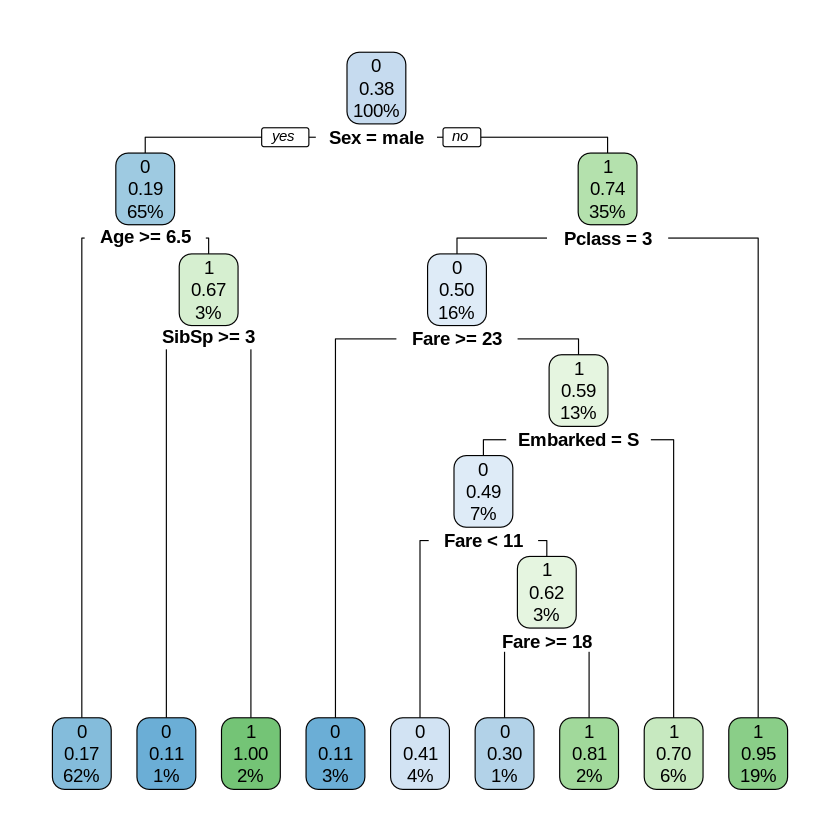

In [45]:
library (rpart)
library (rpart.plot)
predictors = c ("Pclass", "Sex", "Age", "SibSp",
                 "Parch", "Fare", "Embarked",
                 "ClassGender2")

tree.model = rpart(as.formula(paste("Survived~",
                                    paste(predictors, collapse = "+"))),
                   data=titanic_new)
rpart.plot (tree.model)
tree.model$variable.importance


tree.model = rpart(as.formula(paste("Survived~",paste(predictors, data=titanic_new))))
*   as.formula(): converts a character string into a formula object, which is required by rpart to define the relationship between the target and predictor variables.
*   paste ("Survived~",...): starts constructing the formula string, indicating the Survived is the dependent (target) variable

---
We've made a variable that is better than all other variables (for a DT, anyway) and is used twice before any other variable!
---

#**Attribute Selection using Boruta**

In [46]:
pkgs <- c("caret", "Boruta", "randomForest")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [47]:
library(caret)
library(Boruta)
library(randomForest)

randomForest: an ensemble of DT

In [53]:
credit_data = read.csv("credit.csv", stringsAsFactors = TRUE)

Boruta is a great method for attribute selection. It uses random forest as the base for identifying which attributes are significant, but it works with any classification method.

Create a boruta object:

In [54]:
boruta_credit = Boruta(class ~ .,
                       data = credit_data,
                       doTrace = 2,
                       maxRuns = 50)
boruta_credit$finalDecision

 1. run of importance source...

 2. run of importance source...

 3. run of importance source...

 4. run of importance source...

 5. run of importance source...

 6. run of importance source...

 7. run of importance source...

 8. run of importance source...

 9. run of importance source...

 10. run of importance source...

 11. run of importance source...

After 11 iterations, +15 secs: 

 confirmed 6 attributes: checking_status, credit_amount, credit_history, duration, other_payment_plans and 1 more;

 still have 14 attributes left.


 12. run of importance source...

 13. run of importance source...

 14. run of importance source...

 15. run of importance source...

After 15 iterations, +22 secs: 

 confirmed 1 attribute: purpose;

 still have 13 attributes left.


 16. run of importance source...

 17. run of importance source...

 18. run of importance source...

 19. run of importance source...

After 19 iterations, +27 secs: 

 confirmed 2 attributes: age, installment_comm

checking_status               duration         credit_history 
             Confirmed              Confirmed              Confirmed 
               purpose          credit_amount         savings_status 
             Confirmed              Confirmed              Confirmed 
            employment installment_commitment        personal_status 
             Tentative              Confirmed              Tentative 
         other_parties        residence_since     property_magnitude 
             Tentative               Rejected              Tentative 
                   age    other_payment_plans                housing 
             Confirmed              Confirmed              Tentative 
      existing_credits                    job         num_dependents 
             Tentative              Tentative               Rejected 
         own_telephone         foreign_worker 
              Rejected              Tentative 
Levels: Tentative Confirmed Rejected

maxRuns = 50 is not a lot. Make sure to run more than 50

When you run `boruta_credit$finalDecision`, it returns a vector containing the decision of Boruta for each attribute. The possible decisions are:

*   **Confirmed**: These attributes are deemed important and should be kept for further analysis or modeling.
*   **Rejected**: These attributes are considered unimportant and can be safely removed.
*   **Tentative**: For these attributes, Boruta couldn't make a conclusive decision within the specified `maxRuns`. You might need to increase `maxRuns` or examine them more closely.

A lot of tentatives could just mean need to run more iterations. 500 to 1000 still the same, then, that's probably means that it is not related to the numbers of iterations

Automatically get the selected attributes

In [51]:
getSelectedAttributes(boruta_credit)

[1] "checking_status"        "duration"               "credit_history"        
 [4] "purpose"                "credit_amount"          "savings_status"        
 [7] "employment"             "installment_commitment" "other_parties"         
[10] "age"                    "other_payment_plans"

getSelectedAtrributed(x, withTentative = True) if want the Tentative attributes to be returned as well.

Can construct a new data set but have to remember to add the class!

In [52]:
credit_data_2 = credit_data[,c(getSelectedAttributes(boruta_credit),"class")]

#**Principal Component Analysis**

PCA is a way to change the coordinate system that we use from our starting variables (Petal_Length, Petal_Width, Sepal_Length, Sepal_With for the iris data) into 4 different variables (PC1, PC2, PC3, PC4) where the first one PC1 is the most useful, PC2 is the second most useful, etc.

In [56]:
pca_iris = prcomp(iris[,1:4])

prcomp refines the principal component for these data; no species only the first 4 columns

In [58]:
pca_iris

Standard deviations (1, .., p=4):
[1] 2.0562689 0.4926162 0.2796596 0.1543862

Rotation (n x k) = (4 x 4):
                     PC1         PC2         PC3        PC4
Sepal.Length  0.36138659 -0.65658877  0.58202985  0.3154872
Sepal.Width  -0.08452251 -0.73016143 -0.59791083 -0.3197231
Petal.Length  0.85667061  0.17337266 -0.07623608 -0.4798390
Petal.Width   0.35828920  0.07548102 -0.54583143  0.7536574

We can take a look at the principal components themselves:

In [57]:
pca_iris$rotation

,PC1,PC2,PC3,PC4
Sepal.Length,0.36138659,-0.65658877,0.58202985,0.3154872
Sepal.Width,-0.08452251,-0.73016143,-0.59791083,-0.3197231
Petal.Length,0.85667061,0.17337266,-0.07623608,-0.4798390
Petal.Width,0.35828920,0.07548102,-0.54583143,0.7536574


The standard deviation of the principal components (square root of the eigenvalues) tells you how much of the variance is explained by each of the principal components

In [59]:
pca_iris$sdev

[1] 2.0562689 0.4926162 0.2796596 0.1543862

We want to see the first number as (by far) the largest,and the first 2-3 numbers covering almost everything.
This means PCA is potentially useful

The data transformed according to the PCA space

In [60]:
pca_iris$x

PC1,PC2,PC3,PC4
-2.684126,-0.31939725,0.02791483,0.002262437
-2.714142,0.17700123,0.21046427,0.099026550
-2.888991,0.14494943,-0.01790026,0.019968390
-2.745343,0.31829898,-0.03155937,-0.075575817
-2.728717,-0.32675451,-0.09007924,-0.061258593
-2.280860,-0.74133045,-0.16867766,-0.024200858
-2.820538,0.08946138,-0.25789216,-0.048143106
-2.626145,-0.16338496,0.02187932,-0.045297871
-2.886383,0.57831175,-0.02075957,-0.026744736
-2.672756,0.11377425,0.19763272,-0.056295401


x is the tranformed data

Compare the first data point

In [61]:
iris[1,1:4]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
1,5.1,3.5,1.4,0.2


 With the transformed value

In [62]:
pca_iris$x[1,]

PC1          PC2          PC3          PC4 
-2.684125626 -0.319397247  0.027914828  0.002262437

How did we get value -2.684125626 of PC1, the first principle component for  this data point?

It's a linear combination using PC1:

In [63]:
pca_iris$rotation[,1]

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
  0.36138659  -0.08452251   0.85667061   0.35828920

A linear combination is when we multiply the numbers, one by one

In [64]:
pca_iris$rotation[,1]*iris[1,1:4]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
1,1.843072,-0.2958288,1.199339,0.07165784


In [66]:
pca_iris$x[1,]

PC1          PC2          PC3          PC4 
-2.684125626 -0.319397247  0.027914828  0.002262437

we did not get 1.84, we get -2.68 because we did not scale



 And then add them together:

In [67]:
sum(pca_iris$rotation[,1]*iris[1,1:4])

[1] 2.81824

But for the PCA, the data was first centered:

In [68]:
sum(pca_iris$rotation[,1]*(iris[1,1:4]-pca_iris$center))

[1] -2.684126

Notice that all four numbers (values of all four variables)are transformed into the single PC1 value for the transformed data point. Similarly, all four values make each of the other three values.

The other three principal components are similarly:

In [69]:
sum(pca_iris$rotation[,2]*(iris[1,1:4]-pca_iris$center))
sum(pca_iris$rotation[,3]*(iris[1,1:4]-pca_iris$center))
sum(pca_iris$rotation[,4]*(iris[1,1:4]-pca_iris$center))

[1] -0.3193972

[1] 0.02791483

[1] 0.002262437

Of course, the above is only for illustration so that you understand the transformation being done. The transformation has already been done for you for every data point:

In [70]:
pca_iris$x

PC1,PC2,PC3,PC4
-2.684126,-0.31939725,0.02791483,0.002262437
-2.714142,0.17700123,0.21046427,0.099026550
-2.888991,0.14494943,-0.01790026,0.019968390
-2.745343,0.31829898,-0.03155937,-0.075575817
-2.728717,-0.32675451,-0.09007924,-0.061258593
-2.280860,-0.74133045,-0.16867766,-0.024200858
-2.820538,0.08946138,-0.25789216,-0.048143106
-2.626145,-0.16338496,0.02187932,-0.045297871
-2.886383,0.57831175,-0.02075957,-0.026744736
-2.672756,0.11377425,0.19763272,-0.056295401


Let's compare the original and transformed data through visualization.

 Original data with our usual two variables

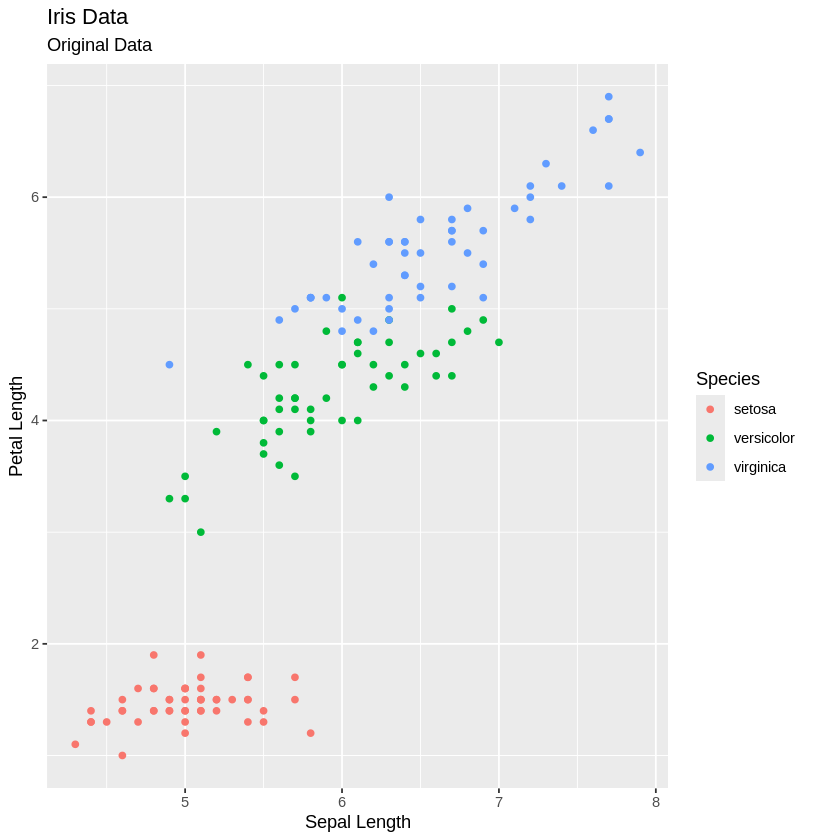

In [71]:
ggplot(iris) +
  ggtitle("Iris Data",
          subtitle="Original Data") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color=Species))

We can see two clusters and one is enlongated, so we might want to split it into two for more compact clusters

Original data with the other two variables

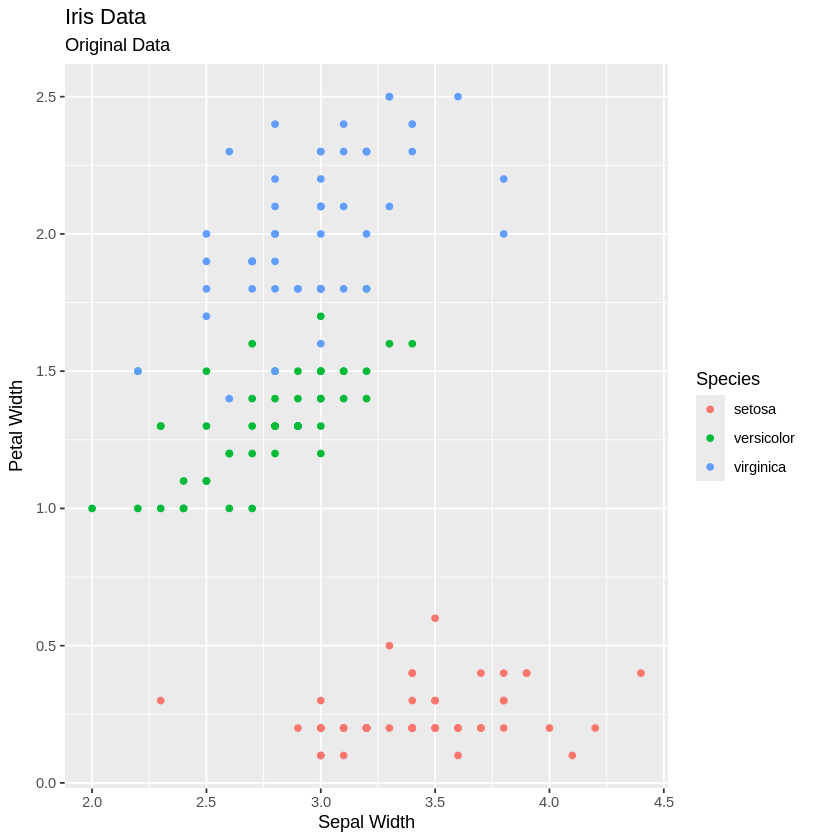

In [72]:
ggplot(iris) +
  ggtitle("Iris Data",
          subtitle="Original Data") +
  xlab("Sepal Width") +
  ylab("Petal Width") +
  geom_point(data = iris,
             mapping = aes(Sepal.Width,
                           Petal.Width,
                           color=Species))

Still see pretty much the same thing

First convert the matrix into a data frame:

In [73]:
iris_transformed = as.data.frame(pca_iris$x)

Add the species

In [74]:
iris_transformed = cbind(iris_transformed,iris$Species)
colnames(iris_transformed)=c(colnames(iris_transformed)[1:4],"Species")

Transformed data with the first two principal components

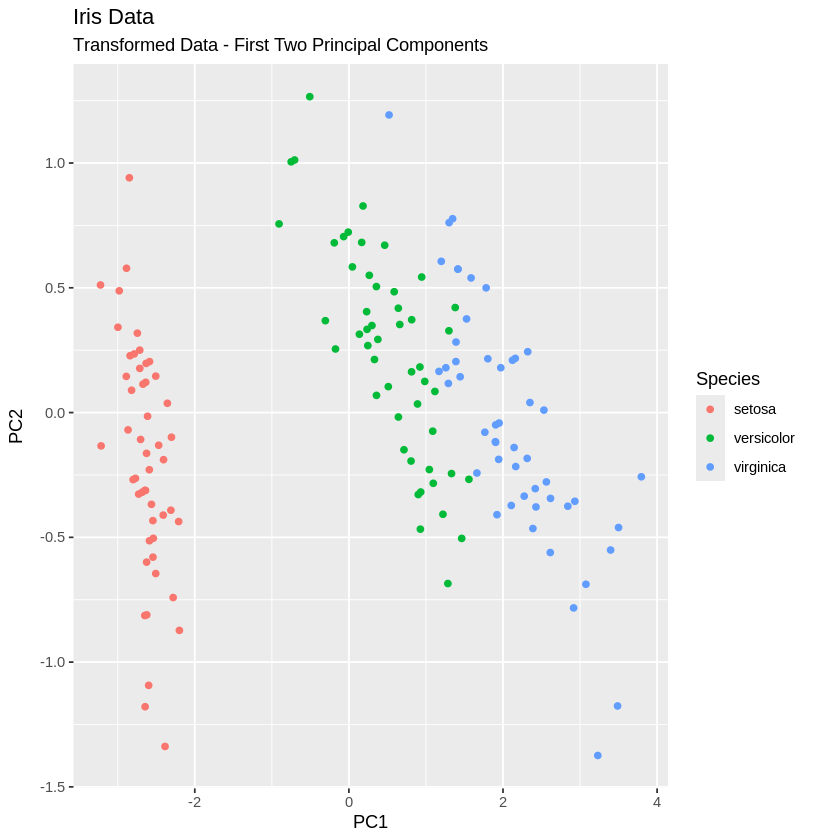

In [75]:
ggplot() +
  ggtitle("Iris Data",
          subtitle="Transformed Data - First Two Principal Components") +
  xlab("PC1") +
  ylab("PC2") +
  geom_point(data=iris_transformed,
             mapping = aes(PC1,
                           PC2,
                           color=Species))

Looks like a useful visualization. Note that we could now draw a line between versicolor and virginica. But the downside is that the axes are no longer easily interpretable

Transformed data with the other two principal components

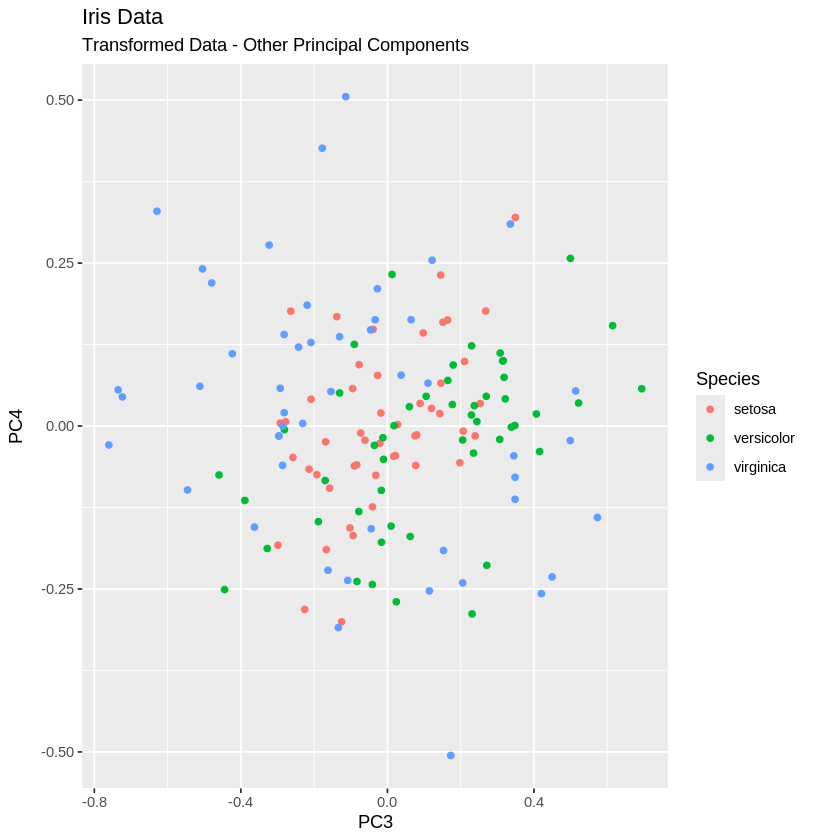

In [76]:
ggplot() +
  ggtitle("Iris Data",
          subtitle="Transformed Data - Other Principal Components") +
  xlab("PC3") +
  ylab("PC4") +
  geom_point(data=iris_transformed,
             mapping = aes(PC3,
                           PC4,
                           color=Species))

Plotting PC3 and PC4 is completely useless! This is what we should expect.

However, it's not always just the first two PCs that are useful.

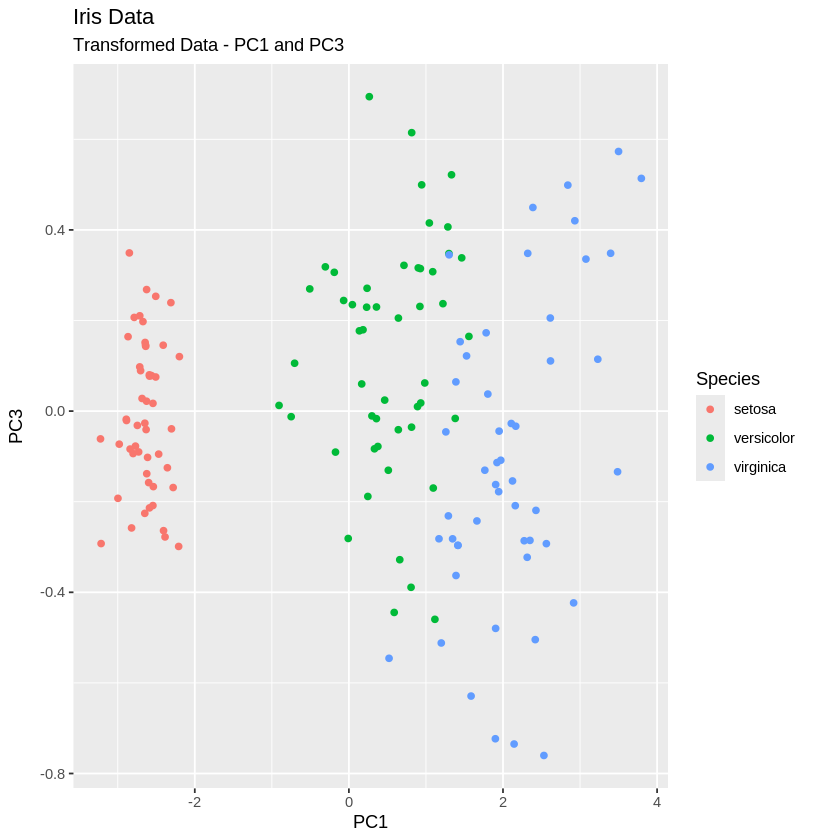

In [77]:
ggplot() +
  ggtitle("Iris Data",
          subtitle="Transformed Data - PC1 and PC3") +
  xlab("PC1") +
  ylab("PC3") +
  geom_point(data=iris_transformed,
             mapping = aes(PC1,
                           PC3,
                           color=Species))